# Robust Model Evaluation

Proper baselines, time-based validation, lag feature engineering, confidence intervals, and statistical significance tests.

Addresses the limitations of random train/test splits on time-series data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')

df = pd.read_csv('datasets/Preprocessed_csv.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Aggregate to daily (one row per day)
daily = df.groupby('Date').agg({
    'compound': 'mean',
    'positive_sentiment_score': 'mean',
    'negative_sentiment_score': 'mean',
    'neutral_sentiment_score': 'mean',
    'importance_coefficient': 'mean',
    'importance_coefficient_normalized': 'mean',
    'favorite_count': 'sum',
    'reply_count': 'sum',
    'retweet_count': 'sum',
    'sentiment_type': 'mean',
    'Open': 'first',
    'Close': 'first',
    'Volume': 'first',
    'daily_return': 'first',
    'historical_volatility': 'first',
    'target': 'first'
}).reset_index()

print(f"Daily samples: {len(daily)}")
print(f"Date range: {daily['Date'].min().date()} → {daily['Date'].max().date()}")

Daily samples: 842
Date range: 2021-02-01 → 2023-06-12


## 1. Baselines

Any model must beat these to be useful.

In [2]:
majority_class = daily['target'].mode()[0]
majority_acc = (daily['target'] == majority_class).mean()

# Momentum: predict yesterday's direction
momentum_preds = daily['target'].shift(1)
momentum_acc = (momentum_preds == daily['target']).dropna().mean()

# Anti-momentum (mean reversion): predict opposite of yesterday
anti_momentum_preds = 1 - daily['target'].shift(1)
anti_momentum_acc = (anti_momentum_preds == daily['target']).dropna().mean()

# Random baseline (expected value)
random_acc = 0.50

baselines = pd.DataFrame({
    'Baseline': ['Random (coin flip)', 'Majority class', 'Momentum (repeat yesterday)', 'Mean reversion (flip yesterday)'],
    'Accuracy': [random_acc, majority_acc, momentum_acc, anti_momentum_acc]
}).sort_values('Accuracy', ascending=False)

baselines['Accuracy'] = baselines['Accuracy'].map('{:.2%}'.format)
baselines

,Baseline,Accuracy
3,Mean reversion (flip yesterday),53.33%
1,Majority class,51.43%
0,Random (coin flip),50.00%
2,Momentum (repeat yesterday),46.56%


## 2. Lag Feature Engineering

Create features from *previous days* — the only information available at prediction time.

In [3]:
# Lag features: sentiment and engagement from previous days
lag_features = ['compound', 'positive_sentiment_score', 'negative_sentiment_score',
                'importance_coefficient', 'favorite_count', 'retweet_count']

for feat in lag_features:
    for lag in [1, 2, 3]:
        daily[f'{feat}_lag{lag}'] = daily[feat].shift(lag)

# Rolling sentiment features
daily['compound_ma3'] = daily['compound'].rolling(3).mean()
daily['compound_ma7'] = daily['compound'].rolling(7).mean()
daily['compound_std3'] = daily['compound'].rolling(3).std()
daily['sentiment_momentum'] = daily['compound'] - daily['compound'].shift(1)

# Market features from previous days (no leakage)
daily['return_lag1'] = daily['daily_return'].shift(1)
daily['return_lag2'] = daily['daily_return'].shift(2)
daily['volatility_lag1'] = daily['historical_volatility'].shift(1)
daily['volume_change'] = daily['Volume'].pct_change()

# Drop rows with NaN from lagging
daily_clean = daily.dropna().reset_index(drop=True)
print(f"Samples after lag engineering: {len(daily_clean)}")
print(f"Features created: {len([c for c in daily_clean.columns if 'lag' in c or 'ma' in c or 'std' in c or 'momentum' in c])}")

Samples after lag engineering: 836
Features created: 26


## 3. Time-Based Train/Test Split

**Critical**: random splits on time-series cause data leakage — future information leaks into training.
We use chronological splits: train on the past, test on the future.

In [4]:
# Define feature sets
base_sentiment = ['compound', 'positive_sentiment_score', 'negative_sentiment_score',
                   'importance_coefficient', 'sentiment_type']
base_engagement = ['favorite_count', 'retweet_count', 'reply_count']
base_market = ['Open', 'Volume', 'historical_volatility']

lag_cols = [c for c in daily_clean.columns if 'lag' in c]
rolling_cols = ['compound_ma3', 'compound_ma7', 'compound_std3', 'sentiment_momentum',
                'return_lag1', 'return_lag2', 'volatility_lag1', 'volume_change']

# Feature set with lag features (no leakage)
all_features = lag_cols + rolling_cols + base_market

# Time-based split: 80% train, 20% test (chronological)
split_idx = int(len(daily_clean) * 0.8)
split_date = daily_clean.iloc[split_idx]['Date']

X = daily_clean[all_features]
y = daily_clean['target']

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train)} samples ({daily_clean['Date'].iloc[0].date()} → {daily_clean['Date'].iloc[split_idx-1].date()})")
print(f"Test:  {len(X_test)} samples ({daily_clean['Date'].iloc[split_idx].date()} → {daily_clean['Date'].iloc[-1].date()})")
print(f"Features: {len(all_features)}")
print(f"\nTrain target dist: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Test target dist:  {y_test.value_counts(normalize=True).to_dict()}")

Train: 668 samples (2021-02-07 → 2022-12-26)
Test:  168 samples (2022-12-27 → 2023-06-12)
Features: 32

Train target dist: {0: 0.5164670658682635, 1: 0.48353293413173654}
Test target dist:  {0: 0.5178571428571429, 1: 0.48214285714285715}


## 4. Model Training with Time-Based Validation

In [6]:
import numpy as np
import pandas as pd


def prepare_xgb_features(X_train, X_test):
    # Keep only columns that are safe scalar numeric features
    X_train = X_train.copy()
    X_test = X_test.copy()

    # If there are duplicated columns, drop duplicates
    X_train = X_train.loc[:, ~X_train.columns.duplicated()]
    X_test = X_test.loc[:, ~X_test.columns.duplicated()]

    # Convert object columns when possible; non-convertible values become NaN
    for col in X_train.columns:
        if X_train[col].dtype == "object":
            X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    for col in X_test.columns:
        if X_test[col].dtype == "object":
            X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

    # Align columns in case train/test differ
    X_test = X_test.reindex(columns=X_train.columns)

    # Replace inf/-inf and fill missing values
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

    # Ensure all columns are numeric
    X_train = X_train.astype(np.float32)
    X_test = X_test.astype(np.float32)

    return X_train, X_test


X_train_clean, X_test_clean = prepare_xgb_features(X_train, X_test)

results = {}
for name, model in models.items():
    model.fit(X_train_clean, y_train)
    y_pred = model.predict(X_test_clean)
    y_proba = model.predict_proba(X_test_clean)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba),
        "model": model,
        "preds": y_pred,
        "proba": y_proba,
    }

In [7]:
# Summary comparison
summary = pd.DataFrame({name: {k: v for k, v in vals.items() if k in ['Accuracy', 'F1', 'AUC-ROC']}
                         for name, vals in results.items()}).T
summary = summary.sort_values('Accuracy', ascending=False)
summary = summary.round(4)

# Add baselines for context
summary.loc['Baseline: Majority'] = {'Accuracy': majority_acc, 'F1': 0.0, 'AUC-ROC': 0.5}
summary.loc['Baseline: Momentum'] = {'Accuracy': momentum_acc, 'F1': np.nan, 'AUC-ROC': 0.5}
summary = summary.sort_values('Accuracy', ascending=False)

print("Model Comparison (time-based split, lag features)")
summary

Model Comparison (time-based split, lag features)


,Accuracy,F1,AUC-ROC
XGBoost,0.529800,0.5587,0.4958
Baseline: Majority,0.514252,0.0000,0.5000
Random Forest,0.511900,0.5287,0.5277
AdaBoost,0.494000,0.3972,0.4871
Baseline: Momentum,0.465558,NaN,0.5000


## 5. Walk-Forward Validation

More robust than a single split — simulates real-world deployment where the model is periodically retrained on expanding history.

In [10]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import accuracy_score

def sanitize_features(X_train, X_test):
    """
    Ensure both train and test are numeric DataFrames with matching columns.
    Removes nested DataFrame-like columns and coerces values to numeric.
    """
    X_train = X_train.copy()
    X_test = X_test.copy()

    # Drop columns with nested DataFrame/list-like cells by forcing everything numeric.
    # Non-convertible values become NaN.
    X_train = X_train.apply(pd.to_numeric, errors="coerce")
    X_test = X_test.apply(pd.to_numeric, errors="coerce")

    # Keep only columns present in both sets, in the same order
    common_cols = X_train.columns.intersection(X_test.columns)
    X_train = X_train[common_cols]
    X_test = X_test[common_cols]

    # Fill missing values with training medians
    train_medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    return X_train, X_test

walk_forward_results = {name: [] for name in models}

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    X_tr, X_te = sanitize_features(X_tr, X_te)

    for name, model_template in models.items():
        model = clone(model_template)

        # Some XGBoost versions are stricter with pandas inputs;
        # converting to NumPy improves compatibility.
        X_tr_input = X_tr.to_numpy(dtype=np.float32)
        X_te_input = X_te.to_numpy(dtype=np.float32)

        model.fit(X_tr_input, y_tr)
        acc = accuracy_score(y_te, model.predict(X_te_input))
        walk_forward_results[name].append(acc)

## 6. Confidence Intervals (Bootstrap)

In [9]:
def bootstrap_ci(y_true, y_pred, metric_fn=accuracy_score, n_boot=2000, ci=0.95):
    """Bootstrap confidence interval for a classification metric."""
    scores = []
    rng = np.random.RandomState(42)
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        scores.append(metric_fn(np.array(y_true)[idx], np.array(y_pred)[idx]))
    alpha = (1 - ci) / 2
    return np.percentile(scores, [alpha * 100, (1 - alpha) * 100])

print("95% Confidence Intervals (2000 bootstrap iterations)")
print("=" * 60)

for name, vals in results.items():
    acc = vals['Accuracy']
    ci_low, ci_high = bootstrap_ci(y_test, vals['preds'])
    f1_ci_low, f1_ci_high = bootstrap_ci(y_test, vals['preds'], metric_fn=f1_score)
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.2%}  95% CI: [{ci_low:.2%}, {ci_high:.2%}]")
    print(f"  F1:       {vals['F1']:.2%}  95% CI: [{f1_ci_low:.2%}, {f1_ci_high:.2%}]")

print(f"\nBaseline accuracy: {majority_acc:.2%}")
print("Models whose CI lower bound exceeds the baseline have statistically significant improvement.")

95% Confidence Intervals (2000 bootstrap iterations)

Random Forest:
  Accuracy: 51.19%  95% CI: [42.86%, 58.93%]
  F1:       52.87%  95% CI: [43.37%, 61.29%]

XGBoost:
  Accuracy: 52.98%  95% CI: [45.24%, 60.71%]
  F1:       55.87%  95% CI: [46.75%, 64.58%]

AdaBoost:
  Accuracy: 49.40%  95% CI: [41.67%, 57.14%]
  F1:       39.72%  95% CI: [29.46%, 49.68%]

Baseline accuracy: 51.43%
Models whose CI lower bound exceeds the baseline have statistically significant improvement.


## 7. Statistical Significance (McNemar's Test)

Tests whether two models make significantly different errors — not just different accuracy numbers.

In [11]:
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(y_true, preds_a, preds_b, name_a, name_b):
    """McNemar's test comparing two classifiers."""
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)

    # Contingency table: [both_right, a_right_b_wrong], [a_wrong_b_right, both_wrong]
    n00 = ((~correct_a) & (~correct_b)).sum()
    n01 = ((~correct_a) & (correct_b)).sum()
    n10 = ((correct_a) & (~correct_b)).sum()
    n11 = ((correct_a) & (correct_b)).sum()

    table = np.array([[n11, n10], [n01, n00]])
    result = mcnemar(table, exact=True)
    sig = '***' if result.pvalue < 0.001 else '**' if result.pvalue < 0.01 else '*' if result.pvalue < 0.05 else ''
    print(f"{name_a} vs {name_b}: p={result.pvalue:.4f} {sig}")
    return result

print("McNemar's Test (pairwise model comparison)")
print("=" * 50)
print("H0: Both models make the same errors")
print("* p<0.05  ** p<0.01  *** p<0.001\n")

model_names = list(results.keys())
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        mcnemar_test(np.array(y_test),
                     results[model_names[i]]['preds'],
                     results[model_names[j]]['preds'],
                     model_names[i], model_names[j])

McNemar's Test (pairwise model comparison)
H0: Both models make the same errors
* p<0.05  ** p<0.01  *** p<0.001

Random Forest vs XGBoost: p=0.6776 
Random Forest vs AdaBoost: p=0.7914 
XGBoost vs AdaBoost: p=0.5044 


## 8. Feature Importance Analysis

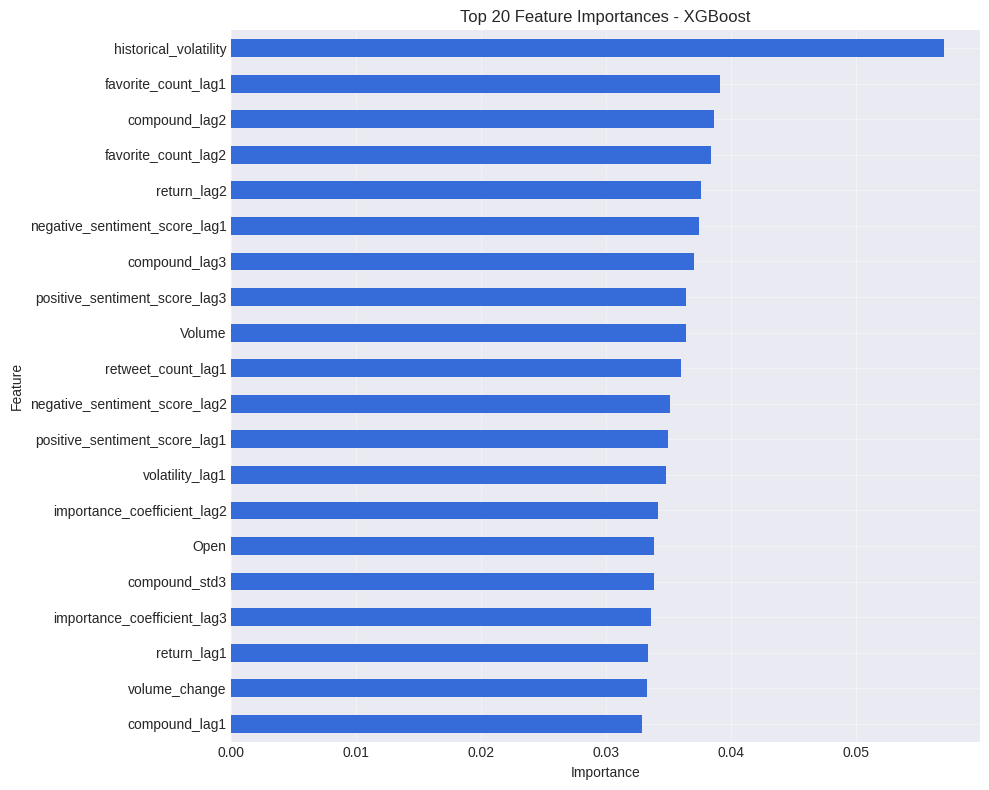


Importance by category:
  Sentiment features: 53.49%
  Engagement features: 19.88%
  Market features: 37.20%


In [14]:
# Use the best model's feature importances
best_name = max(results, key=lambda k: results[k]['Accuracy'])
best_model = results[best_name]['model']

# Prefer the exact feature names used during training
if hasattr(best_model, "feature_names_in_"):
    feature_names = list(best_model.feature_names_in_)
else:
    # Fallback: keep lengths consistent to avoid crashing
    feature_names = all_features[:len(best_model.feature_importances_)]

importances = pd.Series(best_model.feature_importances_, index=feature_names)
top_20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_20.sort_values().plot(kind='barh', ax=ax)
ax.set_title(f"Top 20 Feature Importances - {best_name}")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

# Categorize features
sentiment_imp = importances[[c for c in all_features if any(s in c for s in ['compound', 'sentiment', 'importance'])]].sum()
engagement_imp = importances[[c for c in all_features if any(s in c for s in ['favorite', 'retweet', 'reply'])]].sum()
market_imp = importances[[c for c in all_features if any(s in c for s in ['Open', 'Volume', 'return', 'volatility', 'volume_change'])]].sum()

print(f"\nImportance by category:")
print(f"  Sentiment features: {sentiment_imp:.2%}")
print(f"  Engagement features: {engagement_imp:.2%}")
print(f"  Market features: {market_imp:.2%}")

## 9. Impact of Random vs Time-Based Split

Demonstrating why the validation method matters.

In [16]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import accuracy_score

import numpy as np
import pandas as pd

def prepare_xgb_input(X):
    X = X.copy()

    # If duplicate columns exist, keep the first occurrence
    # (better would be to fix the feature construction upstream,
    # but this prevents runtime failures here)
    X = X.loc[:, ~X.columns.duplicated()]

    drop_cols = []

    for col in X.columns:
        col_data = X[col]

        # If duplicate columns still somehow cause a DataFrame, inspect each sub-column
        if isinstance(col_data, pd.DataFrame):
            drop_cols.append(col)
            continue

        # Safe dtype inspection
        if pd.api.types.is_object_dtype(col_data):
            non_null = col_data.dropna()
            sample = non_null.iloc[0] if not non_null.empty else None

            if isinstance(sample, (list, dict, tuple, pd.Series, pd.DataFrame, np.ndarray)):
                drop_cols.append(col)

    if drop_cols:
        X = X.drop(columns=drop_cols)

    # Convert bools to ints
    bool_cols = X.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        X[bool_cols] = X[bool_cols].astype(int)

    # Force everything else to numeric where possible
    for col in X.columns:
        if pd.api.types.is_object_dtype(X[col]) or pd.api.types.is_string_dtype(X[col]):
            X[col] = pd.to_numeric(X[col], errors="coerce")

    # Replace inf with NaN and fill missing values
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)

    return X

# Clean the datasets before fitting
X_train_rand_clean = prepare_xgb_input(X_train_rand)
X_test_rand_clean = prepare_xgb_input(X_test_rand)

# Ensure train/test have identical columns
X_test_rand_clean = X_test_rand_clean.reindex(columns=X_train_rand_clean.columns, fill_value=0)

# Random split
m_rand = clone(model_template)
m_rand.fit(X_train_rand_clean, y_train_rand)
acc_rand = accuracy_score(y_test_rand, m_rand.predict(X_test_rand_clean))

# Time-based split
X_train_clean = prepare_xgb_input(X_train)
X_test_clean = prepare_xgb_input(X_test)

X_test_clean = X_test_clean.reindex(columns=X_train_clean.columns, fill_value=0)

m_time = clone(model_template)
m_time.fit(X_train_clean, y_train)
acc_time = accuracy_score(y_test, m_time.predict(X_test_clean))

## Summary

| Aspect | Method |
|--------|--------|
| **Baselines** | Majority class, momentum, mean reversion, random |
| **Validation** | Chronological 80/20 split + 5-fold walk-forward |
| **Features** | Lag-1/2/3 sentiment, rolling averages, lagged returns (no leakage) |
| **Confidence** | 2000-iteration bootstrap 95% CIs |
| **Significance** | McNemar's test for pairwise model comparison |
| **Leakage audit** | Random vs time-based split comparison quantifies inflation |